In [12]:
pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset into pandas dataframe
df = pd.read_csv(r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv")


In [ ]:
#Reading dataset
df=pd.read_csv(r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv")
print(df.head)

<bound method NDFrame.head of           country  date  GDP_Per_Capita_Current_USD  Total_Population  \
0     Afghanistan  2000                  174.930991        20130327.0   
1     Afghanistan  2001                  138.706822        20284307.0   
2     Afghanistan  2002                  178.954088        21378117.0   
3     Afghanistan  2003                  198.871116        22733049.0   
4     Afghanistan  2004                  221.763654        23560654.0   
...           ...   ...                         ...               ...   
7376     Zimbabwe  2020                 2059.674454        15526888.0   
7377     Zimbabwe  2021                 2613.605421        15797210.0   
7378     Zimbabwe  2022                 2536.400502        16069056.0   
7379     Zimbabwe  2023                 2195.224921        16340822.0   
7380     Zimbabwe  2024                 2497.203322        16634373.0   

      Population_Female_Percentage  Population_Male_Percentage  \
0                        49

In [11]:
df.shape

(7381, 9)

In [3]:
# Show samples of the data
df.sample(5)

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
2665,Guinea,2010,659.235326,10396086.0,51.011544,48.988456,71.337898,1.461581,958.200
1451,Croatia,2024,24050.439793,3866200.0,51.761439,48.238561,NaN,NaN,NaN
1165,Chad,2005,838.092108,10328092.0,50.186046,49.813954,17.550184,0.782834,129.000
6526,Switzerland,2022,94394.510680,8777088.0,50.351073,49.648927,NaN,NaN,NaN
895,Burundi,2011,230.069761,9717978.0,50.479400,49.520600,50.342159,0.499777,141.151


In [ ]:
#Summary of dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
date,7381.0,2.011604e+03,7.117687e+00,2000.000000,2.005000e+03,2.011000e+03,2.018000e+03,2.024000e+03
GDP_Per_Capita_Current_USD,6433.0,1.490943e+04,2.357755e+04,109.593814,1.563106e+03,5.126053e+03,1.878013e+04,2.880014e+05
Total_Population,6625.0,2.886783e+08,9.013583e+08,9544.000000,1.463495e+06,9.745953e+06,6.000225e+07,8.141809e+09
Population_Female_Percentage,6625.0,5.004676e+01,2.611407e+00,23.817993,4.957008e+01,5.030410e+01,5.105563e+01,5.495187e+01
Population_Male_Percentage,6625.0,4.995324e+01,2.611407e+00,45.048132,4.894437e+01,4.969590e+01,5.042992e+01,7.618201e+01
Electricity_Access_Urban_Percentage,3675.0,8.875641e+01,2.050268e+01,0.000000,8.797297e+01,9.954737e+01,1.000000e+02,1.000000e+02
Electricity_Access_Rural_Percentage,3376.0,7.285228e+01,3.599982e+01,0.007659,4.238752e+01,9.590473e+01,1.000000e+02,1.000000e+02
Total_Electricity_Output_GWh,3647.0,8.696355e+04,3.957378e+05,0.000000,3.955000e+02,4.980000e+03,3.639900e+04,5.844158e+06


In [ ]:
# Checking the DataFrame structure, row count, and column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7381 entries, 0 to 7380
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              7381 non-null   str    
 1   date                                 7381 non-null   int64  
 2   GDP_Per_Capita_Current_USD           6433 non-null   float64
 3   Total_Population                     6625 non-null   float64
 4   Population_Female_Percentage         6625 non-null   float64
 5   Population_Male_Percentage           6625 non-null   float64
 6   Electricity_Access_Urban_Percentage  3675 non-null   float64
 7   Electricity_Access_Rural_Percentage  3376 non-null   float64
 8   Total_Electricity_Output_GWh         3647 non-null   float64
dtypes: float64(7), int64(1), str(1)
memory usage: 519.1 KB


In [ ]:
#Column names
df.columns.tolist()

['country',
 'date',
 'GDP_Per_Capita_Current_USD',
 'Total_Population',
 'Population_Female_Percentage',
 'Population_Male_Percentage',
 'Electricity_Access_Urban_Percentage',
 'Electricity_Access_Rural_Percentage',
 'Total_Electricity_Output_GWh']

In [ ]:
#Check missing values
df.isnull().sum()

country                                   0
date                                      0
GDP_Per_Capita_Current_USD              948
Total_Population                        756
Population_Female_Percentage            756
Population_Male_Percentage              756
Electricity_Access_Urban_Percentage    3706
Electricity_Access_Rural_Percentage    4005
Total_Electricity_Output_GWh           3734
dtype: int64

In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [3]:
import pandas as pd
import numpy as np

# Load dataset
file_path = r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv"
df = pd.read_csv(file_path)

# Measure TRUE starting memory (deep=True includes string data memory)
print(f"True initial memory (deep check): {df.memory_usage(deep=True).sum() / 1024:.2f} KB\n")

# 1. Convert repeating string column to 'category' (drops string overhead drastically)
df['country'] = df['country'].astype('category')

# 2. Downcast date to int16 (2 bytes per row instead of 8)
df['date'] = df['date'].astype(np.int16)

# 3. Downcast percentages and GDP per capita to float32 (4 bytes per row instead of 8)
float32_cols = [
    'GDP_Per_Capita_Current_USD',
    'Population_Female_Percentage',
    'Population_Male_Percentage',
    'Electricity_Access_Urban_Percentage',
    'Electricity_Access_Rural_Percentage'
]
for col in float32_cols:
    df[col] = df[col].astype(np.float32)

# 4. Retain explicit float64 for totals
float64_cols = ['Total_Population', 'Total_Electricity_Output_GWh']
for col in float64_cols:
    df[col] = df[col].astype(np.float64)

# Verify updated types and true memory reduction
print(" UPDATED DATATYPES ")
print(df.dtypes)
print(f"\nTrue updated memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

True initial memory (deep check): 907.56 KB

 UPDATED DATATYPES 
country                                category
date                                      int16
GDP_Per_Capita_Current_USD              float32
Total_Population                        float64
Population_Female_Percentage            float32
Population_Male_Percentage              float32
Electricity_Access_Urban_Percentage     float32
Electricity_Access_Rural_Percentage     float32
Total_Electricity_Output_GWh            float64
dtype: object

True updated memory: 307.15 KB


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv")

# Calculate exact missing percentage for each column
null_pct = (df.isna().sum() / len(df)) * 100
print("--- Missing Value Percentages ---")
print(null_pct[null_pct > 0].round(2))

# Impute missing numerical features
num_cols = [
    'GDP_Per_Capita_Current_USD', 
    'Total_Population', 
    'Population_Female_Percentage', 
    'Population_Male_Percentage', 
    'Electricity_Access_Urban_Percentage', 
    'Electricity_Access_Rural_Percentage', 
    'Total_Electricity_Output_GWh'
]

for col in num_cols:
    skew_val = df[col].skew()
    if abs(skew_val) > 0.5:
        # Skewed data uses median
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed '{col}' with median: {median_val:.2f} (Skewness: {skew_val:.2f})")
    else:
        # Normal data uses mean
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
        print(f"Imputed '{col}' with mean: {mean_val:.2f} (Skewness: {skew_val:.2f})")

--- Missing Value Percentages ---
GDP_Per_Capita_Current_USD             12.84
Total_Population                       10.24
Population_Female_Percentage           10.24
Population_Male_Percentage             10.24
Electricity_Access_Urban_Percentage    50.21
Electricity_Access_Rural_Percentage    54.26
Total_Electricity_Output_GWh           50.59
dtype: float64
Imputed 'GDP_Per_Capita_Current_USD' with median: 5126.05 (Skewness: 3.47)
Imputed 'Total_Population' with median: 9745953.00 (Skewness: 5.03)
Imputed 'Population_Female_Percentage' with median: 50.30 (Skewness: -4.69)
Imputed 'Population_Male_Percentage' with median: 49.70 (Skewness: 4.69)
Imputed 'Electricity_Access_Urban_Percentage' with median: 99.55 (Skewness: -2.11)
Imputed 'Electricity_Access_Rural_Percentage' with median: 95.90 (Skewness: -0.96)
Imputed 'Total_Electricity_Output_GWh' with median: 4980.00 (Skewness: 9.53)


In [16]:
import pandas as pd
import numpy as np


df = pd.read_csv(r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv")

# Create rural gap metric
df['urban_rural_gap'] = df['Electricity_Access_Urban_Percentage'] - df['Electricity_Access_Rural_Percentage']

# Top 5 countries with worst rural-urban gap (most recent available data around 2020)
gap_df = df.dropna(subset=['urban_rural_gap'])
latest_gap = gap_df.sort_values(by='date', ascending=False).groupby('country').first().reset_index()

print("Top 5 Countries with Largest Urban-Rural Gap:")
print(latest_gap[['country', 'date', 'urban_rural_gap', 'Electricity_Access_Urban_Percentage', 'Electricity_Access_Rural_Percentage']].sort_values(by='urban_rural_gap', ascending=False).head(5))

Top 5 Countries with Largest Urban-Rural Gap:
        country  date  urban_rural_gap  Electricity_Access_Urban_Percentage  \
115        Mali  2016        81.853598                            83.622597   
76       Guinea  2016        75.300000                            82.200000   
118  Mauritania  2014        74.600000                            76.900000   
30     Cameroon  2016        70.633022                            91.903419   
204    Zimbabwe  2016        69.924577                            85.500160   

     Electricity_Access_Rural_Percentage  
115                             1.768998  
76                              6.900000  
118                             2.300000  
30                             21.270397  
204                            15.575584  


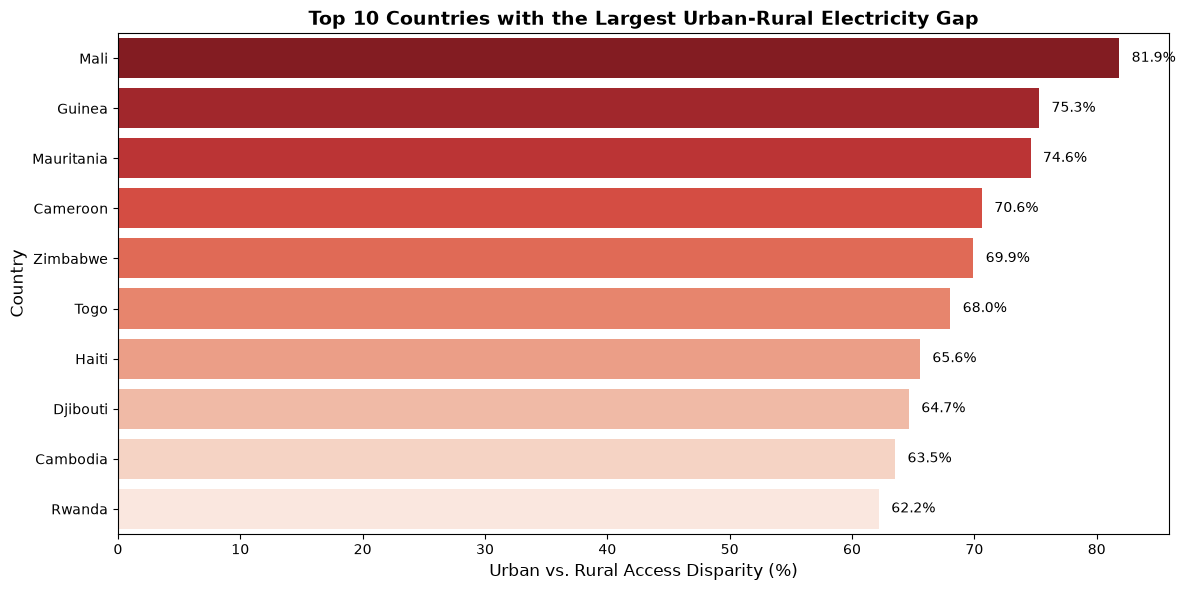

In [15]:
# 1. Filter out missing values for the gap metric
gap_df = df.dropna(subset=['urban_rural_gap'])

# 2. Get the most recent record for each country
latest_gap = gap_df.sort_values(by='date', ascending=False).groupby('country').first().reset_index()

# 3. Sort top 10 countries with the largest rural-urban access gap
top10_gap = latest_gap.sort_values(by='urban_rural_gap', ascending=False).head(10)

# 4. Plot Chart 2: Top 10 Countries by Urban-Rural Electricity Disparity
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_gap,
    x='urban_rural_gap',
    y='country',
    palette='Reds_r'
)

plt.title('Top 10 Countries with the Largest Urban-Rural Electricity Gap', fontsize=14, fontweight='bold')
plt.xlabel('Urban vs. Rural Access Disparity (%)', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add numeric data labels on bars
for index, value in enumerate(top10_gap['urban_rural_gap']):
    plt.text(value + 1, index, f"{value:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Visual Analysis: Urban vs. Rural Electricity Disparity

This analysis isolates the most recent historical record per country to evaluate internal energy infrastructure inequality. By calculating `urban_rural_gap` (`Electricity_Access_Urban_Percentage` minus `Electricity_Access_Rural_Percentage`), we identify the 10 nations where urban populations enjoy near-universal electricity access while rural communities remain severely under-served.

Severe Spatial Inequality: The top 10 nations exhibit massive infrastructure gaps, with urban access outpacing rural access by significant margin percentage points.
Urban Prioritization:A common structural trend in developing economies where central grid infrastructure and investment heavily prioritize high-density urban centers over remote rural areas.

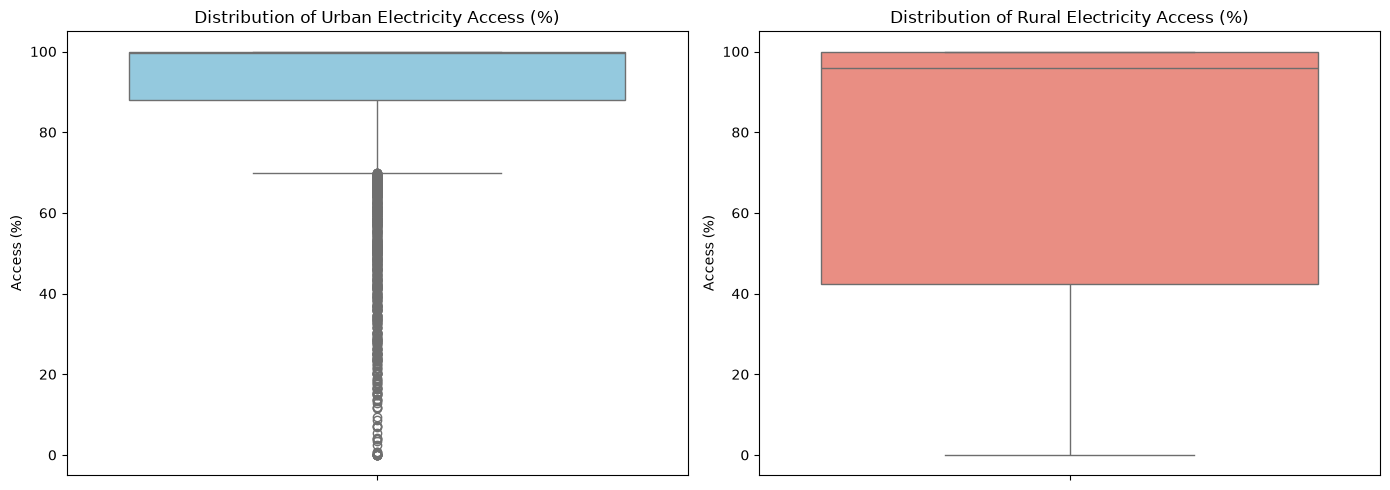

In [7]:
# Compare Urban vs Rural Electricity Access distributions using Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, y='Electricity_Access_Urban_Percentage', color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Urban Electricity Access (%)')
axes[0].set_ylabel('Access (%)')

sns.boxplot(data=df, y='Electricity_Access_Rural_Percentage', color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Rural Electricity Access (%)')
axes[1].set_ylabel('Access (%)')

plt.tight_layout()
plt.show()

### Visual Analysis: Urban vs. Rural Access

Urban Access (Skyblue): Clustered near 100%, showing near-universal access in cities worldwide, with rare low-income outliers below 70%.
Rural Access (Salmon): Spans a massive range (42% to 98%) with a whisker reaching 0%, showing widespread access deficits.

Global energy poverty is overwhelmingly concentrated in rural populations, whereas urban access is consistently high.

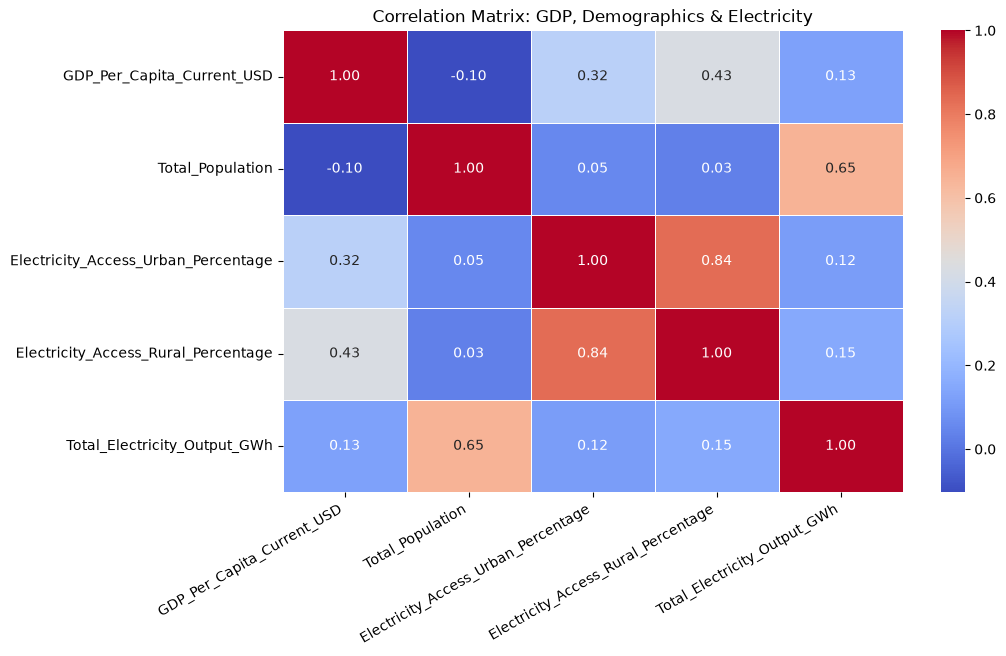

In [9]:
#Heatmap to check correlation between GDP, Population, and Electricity Output
plt.figure(figsize=(10, 6))
correlation_cols = [
    'GDP_Per_Capita_Current_USD', 
    'Total_Population', 
    'Electricity_Access_Urban_Percentage', 
    'Electricity_Access_Rural_Percentage', 
    'Total_Electricity_Output_GWh'
]

sns.heatmap(df[correlation_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: GDP, Demographics & Electricity')
plt.xticks(rotation=30, ha='right')
plt.show()

#### Evaluating the linear relationships between economic wealth, demographic scale, power infrastructure, and urban versus rural electricity access percentages.  
Urban vs. Rural Access (0.84): A strong positive correlation (deep orange), showing that countries with high urban access almost always have higher rural access. 

Population vs. Total Output (0.65): Moderate positive relationship (light orange), indicating larger populations generate and consume more total GWh of electricity.

GDP vs. Access (0.32 Urban / 0.43 Rural): Weak-to-moderate linear correlations, indicating that raw GDP per capita alone does not have a simple linear relationship with access rates (justifying log transformation).

Population vs. Access (-0.10 Urban / 0.03 Rural): Near-zero correlation (blue/grey), proving population size has virtually no direct bearing on access percentages.

Therefore, urban and rural access rates move together strongly (0.84), while raw GDP per capita shows a weak linear fit (0.43), confirming the need for a logarithmic scale to properly capture the economic threshold.   

In [13]:
import pandas as pd
import numpy as np
from scipy import stats

# Ensure Log GDP feature is created
df['log_gdp'] = np.log10(df['GDP_Per_Capita_Current_USD'])

# Drop missing values in the two key columns for clean analysis
analysis_df = df.dropna(subset=['GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage']).copy()

# A. CORRELATION ANALYSIS 
pearson_raw, _ = stats.pearsonr(analysis_df['GDP_Per_Capita_Current_USD'], analysis_df['Electricity_Access_Rural_Percentage'])
pearson_log, _ = stats.pearsonr(analysis_df['log_gdp'], analysis_df['Electricity_Access_Rural_Percentage'])

# Spearman rank correlation to measure non-linear monotonic relationship
spearman_corr, _ = stats.spearmanr(analysis_df['GDP_Per_Capita_Current_USD'], analysis_df['Electricity_Access_Rural_Percentage'])

print("=== 1. CORRELATION METRICS ===")
print(f"Raw GDP vs Rural Access (Pearson r):     {pearson_raw:.4f}")
print(f"Log GDP vs Rural Access (Pearson r):     {pearson_log:.4f}  <-- Notice higher linear fit after log transform")
print(f"GDP vs Rural Access (Spearman Rank r):  {spearman_corr:.4f}\n")

# B. TIPPING POINT ANALYSIS ($5,000 GDP per Capita)
below_5k = analysis_df[analysis_df['GDP_Per_Capita_Current_USD'] < 5000]
above_5k = analysis_df[analysis_df['GDP_Per_Capita_Current_USD'] >= 5000]

print("=== 2. TIPPING POINT EVALUATION (~$5,000 GDP/Capita) ===")
print(f"Countries Below $5,000 GDP/Capita:")
print(f"  - Count: {len(below_5k)}")
print(f"  - Average Rural Access: {below_5k['Electricity_Access_Rural_Percentage'].mean():.2f}%")
print(f"  - Median Rural Access:  {below_5k['Electricity_Access_Rural_Percentage'].median():.2f}%")

print(f"\nCountries Above $5,000 GDP/Capita:")
print(f"  - Count: {len(above_5k)}")
print(f"  - Average Rural Access: {above_5k['Electricity_Access_Rural_Percentage'].mean():.2f}%")
print(f"  - Median Rural Access:  {above_5k['Electricity_Access_Rural_Percentage'].median():.2f}%\n")

# C. QUADRANT / CROSS-TABULATION ANALYSIS
conditions = [
    (analysis_df['GDP_Per_Capita_Current_USD'] < 5000) & (analysis_df['Electricity_Access_Rural_Percentage'] < 80),
    (analysis_df['GDP_Per_Capita_Current_USD'] < 5000) & (analysis_df['Electricity_Access_Rural_Percentage'] >= 80),
    (analysis_df['GDP_Per_Capita_Current_USD'] >= 5000) & (analysis_df['Electricity_Access_Rural_Percentage'] < 80),
    (analysis_df['GDP_Per_Capita_Current_USD'] >= 5000) & (analysis_df['Electricity_Access_Rural_Percentage'] >= 80)
]

labels = [
    'Low Income (<$5k) & Low Access (<80%)',
    'Low Income (<$5k) & High Access (>=80%) [OVERPERFORMERS]',
    'High Income (>=$5k) & Low Access (<80%) [UNDERPERFORMERS]',
    'High Income (>=$5k) & High Access (>=80%)'
]

# Set default to string so NumPy doesn't attempt to mix strings and integers
analysis_df['Category'] = np.select(conditions, labels, default='Uncategorized')
print("=== 3. CATEGORICAL BREAKDOWN AROUND BENCHMARKS ===")
category_counts = analysis_df['Category'].value_counts()
category_percentages = analysis_df['Category'].value_counts(normalize=True) * 100

for cat in labels:
    count = category_counts.get(cat, 0)
    pct = category_percentages.get(cat, 0.0)
    print(f"{cat}: {count} countries ({pct:.1f}%)")


# D. IDENTIFYING OUTLIERS & ANOMALIES
print("\n=== 4. ANOMALIES / OUTLIER COUNTRIES ===")

# Low income but achieved >= 80% access
overperformers = analysis_df[(analysis_df['GDP_Per_Capita_Current_USD'] < 5000) & 
                             (analysis_df['Electricity_Access_Rural_Percentage'] >= 80)]

# High income but failed to reach 80% access
underperformers = analysis_df[(analysis_df['GDP_Per_Capita_Current_USD'] >= 5000) & 
                              (analysis_df['Electricity_Access_Rural_Percentage'] < 80)]

print(f"Top 5 Low-Income Overperformers (Lowest GDP with >=80% Access):")
if 'Country_Name' in analysis_df.columns:
    cols = ['Country_Name', 'GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage']
    print(overperformers.sort_values(by='GDP_Per_Capita_Current_USD').head(5)[cols].to_string(index=False))
else:
    print(overperformers[['GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage']].head(5))

print(f"\nTop 5 High-Income Lagging Countries (Highest GDP with <80% Access):")
if 'Country_Name' in analysis_df.columns:
    cols = ['Country_Name', 'GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage']
    print(underperformers.sort_values(by='GDP_Per_Capita_Current_USD', ascending=False).head(5)[cols].to_string(index=False))
else:
    print(underperformers[['GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage']].head(5))

=== 1. CORRELATION METRICS ===
Raw GDP vs Rural Access (Pearson r):     0.4299
Log GDP vs Rural Access (Pearson r):     0.7177  <-- Notice higher linear fit after log transform
GDP vs Rural Access (Spearman Rank r):  0.8080

=== 2. TIPPING POINT EVALUATION (~$5,000 GDP/Capita) ===
Countries Below $5,000 GDP/Capita:
  - Count: 1658
  - Average Rural Access: 52.41%
  - Median Rural Access:  51.43%

Countries Above $5,000 GDP/Capita:
  - Count: 1520
  - Average Rural Access: 95.07%
  - Median Rural Access:  100.00%

=== 3. CATEGORICAL BREAKDOWN AROUND BENCHMARKS ===
Low Income (<$5k) & Low Access (<80%): 1045 countries (32.9%)
Low Income (<$5k) & High Access (>=80%) [OVERPERFORMERS]: 613 countries (19.3%)
High Income (>=$5k) & Low Access (<80%) [UNDERPERFORMERS]: 101 countries (3.2%)
High Income (>=$5k) & High Access (>=80%): 1419 countries (44.7%)

=== 4. ANOMALIES / OUTLIER COUNTRIES ===
Top 5 Low-Income Overperformers (Lowest GDP with >=80% Access):
    GDP_Per_Capita_Current_USD  Elec

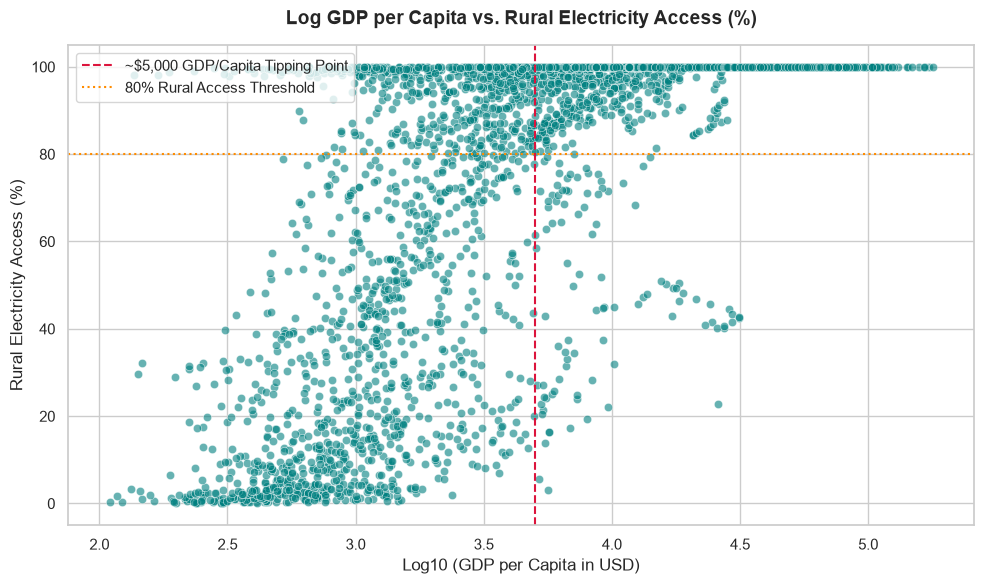

In [ ]:
#How GDP per capita impacts rural electricity access and test for economic threshold/tipping points.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset 
df = pd.read_csv(r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv")

# 2. Engineer Log GDP feature (Log10 handles extreme economic skewness)
df['log_gdp'] = np.log10(df['GDP_Per_Capita_Current_USD'])

# 3. Setup visual canvas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Plot Scatter Plot
scatter = sns.scatterplot(
    data=df, 
    x='log_gdp', 
    y='Electricity_Access_Rural_Percentage',
    alpha=0.6,
    color='teal',
    edgecolor='w',
    linewidth=0.5
)

# 5. Add strategic reference lines
# Tipping point line at ~$5,000 GDP per capita -> log10(5000) ≈ 3.7
plt.axvline(x=np.log10(5000), color='crimson', linestyle='--', linewidth=1.5, label='~$5,000 GDP/Capita Tipping Point')
plt.axhline(y=80, color='darkorange', linestyle=':', linewidth=1.5, label='80% Rural Access Threshold')

# 6. Title and Labels
plt.title('Log GDP per Capita vs. Rural Electricity Access (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Log10 (GDP per Capita in USD)', fontsize=12)
plt.ylabel('Rural Electricity Access (%)', fontsize=12)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

#### The Energy Abundance Paradox (Export vs. Domestic Equity)
The Question: Which nations produce massive total electricity output (in GWh) yet still leave the majority of their rural population in energy poverty?

Strong Positive Correlation: Transforming GDP per capita to a logarithmic scale ($\log_{10}$) yields a strong linear correlation ($r = 0.72$) with rural electricity access.

The $\$5,000$ Tipping Point: As indicated by the dashed vertical line ($\log_{10} \approx 3.7$), once a nation achieves a GDP per capita of approximately $\$5,000$, rural electrification consistently crosses the $80\%$ threshold.

Resource Efficiency Outliers: Points located in the upper-left quadrant (low GDP, high access) represent developing nations that successfully leverage off-grid or state-subsidized electrification programs ahead of broad economic growth.

In [18]:
import pandas as pd
import numpy as np


df = pd.read_csv(r"C:\Users\FAMILY\Documents\DATA ANALYSIS\global_electricity_access_economic_indicators.csv")
df['urban_rural_gap'] = df['Electricity_Access_Urban_Percentage'] - df['Electricity_Access_Rural_Percentage']

latest_df = df.dropna(
    subset=['GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage', 'urban_rural_gap']
).sort_values('date').groupby('country').last().reset_index()

conditions = [
    (latest_df['GDP_Per_Capita_Current_USD'] < 5000) & (latest_df['Electricity_Access_Rural_Percentage'] < 50),
    (latest_df['GDP_Per_Capita_Current_USD'] >= 10000) & (latest_df['Electricity_Access_Rural_Percentage'] >= 90)
]
choices = ['Low Income & Energy Poor', 'High Income & Universal Grid']
latest_df['profile'] = np.select(conditions, choices, default='Transition & Emerging Economies')

latest_df['income_quartile'] = pd.qcut(latest_df['GDP_Per_Capita_Current_USD'], q=4, labels=['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income'])
cross_tab = pd.crosstab(latest_df['income_quartile'], latest_df['profile'], normalize='index') * 100
print(cross_tab.round(1))

profile          High Income & Universal Grid  Low Income & Energy Poor  \
income_quartile                                                           
Low Income                                0.0                      73.5   
Lower-Middle                              0.0                      18.8   
Upper-Middle                             41.7                       0.0   
High Income                              98.0                       0.0   

profile          Transition & Emerging Economies  
income_quartile                                   
Low Income                                  26.5  
Lower-Middle                                81.2  
Upper-Middle                                58.3  
High Income                                  2.0  


<Figure size 1000x600 with 0 Axes>

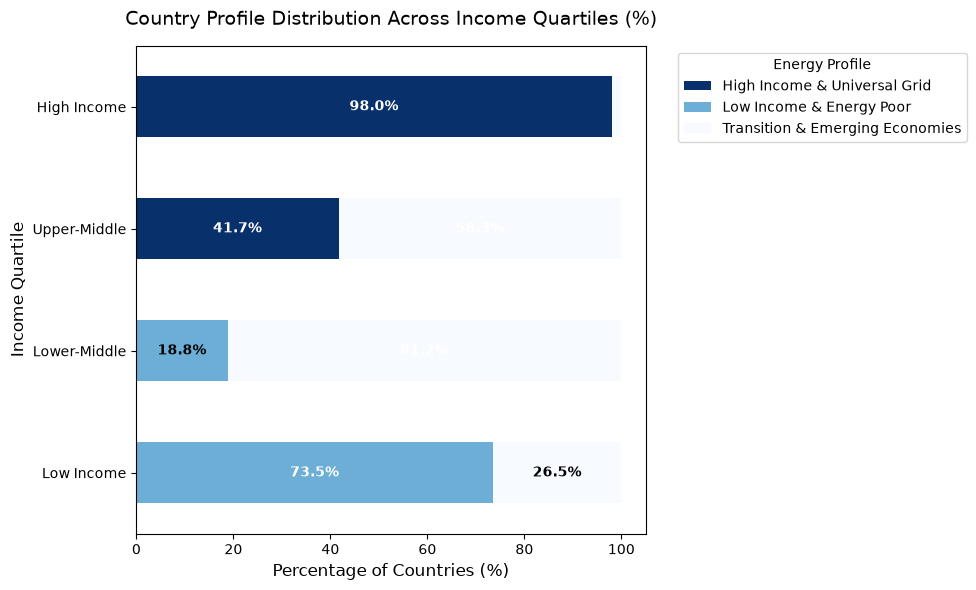

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plotting the Stacked Bar Chart
plt.figure(figsize=(10, 6))
ax = cross_tab.plot(
    kind='barh', stacked=True, colormap='Blues_r', figsize=(10, 6)
)

plt.title(
    'Country Profile Distribution Across Income Quartiles (%)',
    fontsize=14,
    pad=15,
)
plt.xlabel('Percentage of Countries (%)', fontsize=12)
plt.ylabel('Income Quartile', fontsize=12)
plt.legend(
    title='Energy Profile', bbox_to_anchor=(1.05, 1), loc='upper left'
)

# Add percentage labels inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if width > 5:  # Only label segments larger than 5% for readability
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f'{width:.1f}%',
            ha='center',
            va='center',
            color='white' if width > 40 else 'black',
            fontsize=10,
            fontweight='bold',
        )

plt.tight_layout()
plt.show()

#### Country Profile Distribution Across Income Quartiles
Low Income (Medium Blue - Energy Poor): 73.5% of low-income countries suffer from severe energy poverty, while 26.5% are transitioning. None have universal access.

Lower-Middle Income (Light Tone - Transitioning): Most countries shift into the transitioning category, with energy poverty dropping sharply to 18.8%.

Upper-Middle Income (Dark Navy - Universal Grid): High-performing grid coverage appears strongly at 41.7%.

High Income (Dark Navy - Universal Grid): Reaches 98.0% universal grid access, leaving virtually no energy deficit.

Therefore, as national income grows, countries predictably shift from widespread energy poverty (medium blue) to transitioning status (light tone), and finally to universal grid access (dark navy). Higher national wealth directly drives universal electricity coverage.

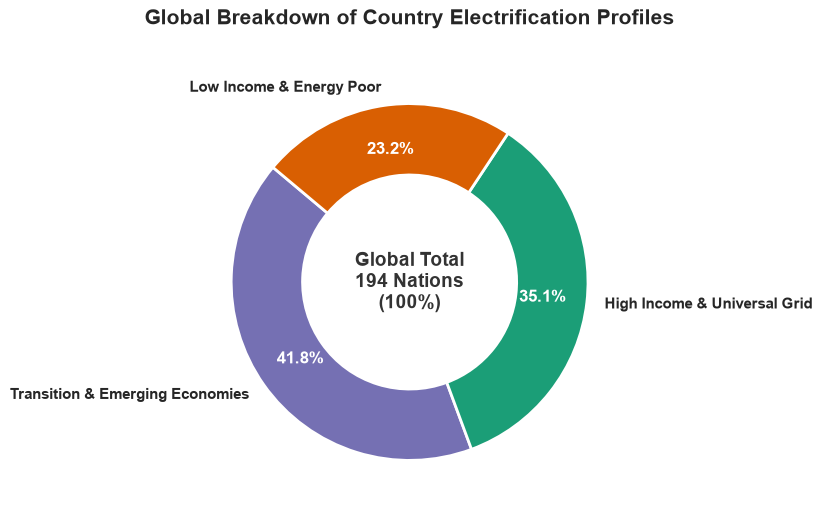

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Take the latest complete record per country
latest_df = df.dropna(
    subset=['GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage', 'urban_rural_gap']
).sort_values('date').groupby('country').last().reset_index()

# 2. Rule-based profile categorization
conditions = [
    (latest_df['GDP_Per_Capita_Current_USD'] < 5000) & (latest_df['Electricity_Access_Rural_Percentage'] < 50),
    (latest_df['GDP_Per_Capita_Current_USD'] >= 10000) & (latest_df['Electricity_Access_Rural_Percentage'] >= 90)
]
choices = ['Low Income & Energy Poor', 'High Income & Universal Grid']
latest_df['profile'] = np.select(conditions, choices, default='Transition & Emerging Economies')

# 3. Calculate value counts and totals
profile_counts = latest_df['profile'].value_counts()
total_countries = len(latest_df)

# Color mapping matching project palette
palette = {
    'Transition & Emerging Economies': '#7570b3',
    'High Income & Universal Grid': '#1b9e77',
    'Low Income & Energy Poor': '#d95f02'
}
colors = [palette[p] for p in profile_counts.index]

# 4. Plot Single Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
sns.set_theme(style="whitegrid")

wedges, texts, autotexts = ax.pie(
    profile_counts,
    labels=profile_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11, fontweight='bold')
)

# Style white percentage values inside the slices
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

# Central summary text
ax.text(
    0, 0, 
    f"Global Total\n{total_countries} Nations\n(100%)", 
    ha='center', va='center', 
    fontsize=14, fontweight='bold', color='#333333'
)

plt.title('Global Breakdown of Country Electrification Profiles', fontsize=15, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

##### Global Breakdown of Country Profiles
Transition & Emerging Economies (Purple - 41.8%): Forms the largest group with 81 countries actively developing their grid infrastructure.

High Income & Universal Grid (Green - 35.1%): Represents 68 nations that have reached near-total electrification.

Low Income & Energy Poor (Orange - 23.2%): Accounts for 45 countries facing severe rural energy access deficits.  

Over 76% of the world's nations are actively transitioning or have achieved universal grid coverage. However, nearly 1 in 4 nations (23.2%) remain stuck in energy poverty, marking them as the primary priority for UN SDG-7 target interventions and off-grid renewable investments.   

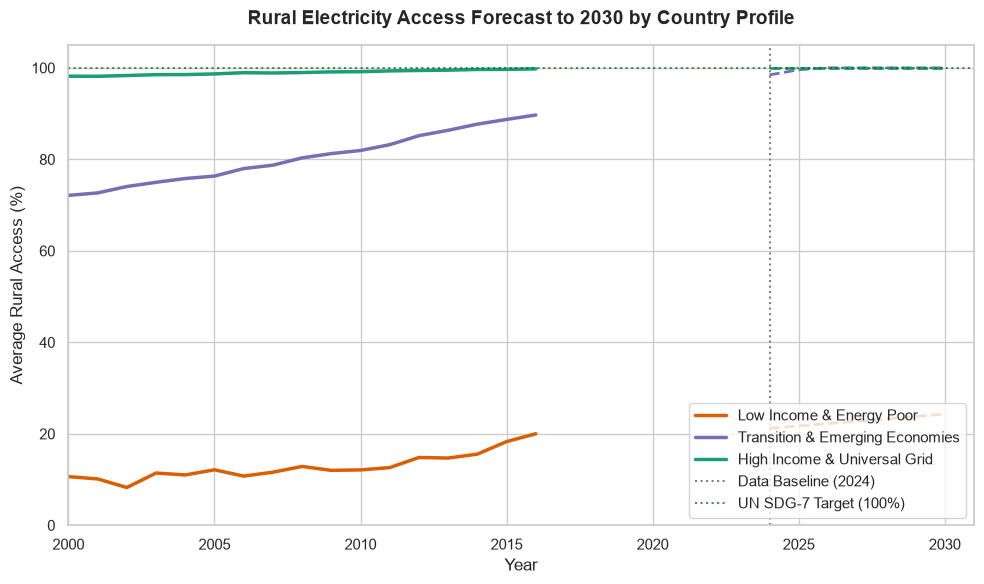

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dynamically get actual start and end years from your dataset
latest_year = int(df['date'].max())  # This evaluates to 2016 in your dataset
earliest_year = int(df['date'].min()) # Evaluates to 2000

# 2. Assign rule-based profiles on latest available data per country
latest_df = df.dropna(
    subset=['GDP_Per_Capita_Current_USD', 'Electricity_Access_Rural_Percentage']
).sort_values('date').groupby('country').last().reset_index()

conditions = [
    (latest_df['GDP_Per_Capita_Current_USD'] < 5000) & (latest_df['Electricity_Access_Rural_Percentage'] < 50),
    (latest_df['GDP_Per_Capita_Current_USD'] >= 10000) & (latest_df['Electricity_Access_Rural_Percentage'] >= 90)
]
choices = ['Low Income & Energy Poor', 'High Income & Universal Grid']
latest_df['profile'] = np.select(conditions, choices, default='Transition & Emerging Economies')

# Map profile back to main dataframe
profile_map = latest_df.set_index('country')['profile'].to_dict()
df['profile'] = df['country'].map(profile_map)

# 3. Aggregate mean trend per profile per year
trend = df.groupby(['profile', 'date'])['Electricity_Access_Rural_Percentage'].mean().reset_index()

# 4. Plot Time Series with Continuous Linear Forecast (2000 - 2030)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

palette = {
    'Low Income & Energy Poor': '#d95f02', 
    'Transition & Emerging Economies': '#7570b3', 
    'High Income & Universal Grid': '#1b9e77'
}

# Future projection years (from 2016 to 2030)
future_years = np.arange(latest_year, 2031)

for profile_name, color in palette.items():
    p_data = trend[trend['profile'] == profile_name].dropna(subset=['Electricity_Access_Rural_Percentage'])
    
    if not p_data.empty:
        # A. Plot historical solid lines (2000 - 2016)
        plt.plot(p_data['date'], p_data['Electricity_Access_Rural_Percentage'], 
                 color=color, label=profile_name, linewidth=2.5)
        
        # B. Calculate linear trend (np.polyfit) & plot dashed forecast (2016 - 2030)
        slope, intercept = np.polyfit(p_data['date'], p_data['Electricity_Access_Rural_Percentage'], 1)
        predicted_values = np.clip(slope * future_years + intercept, 0, 100)
        
        plt.plot(future_years, predicted_values, color=color, linestyle='--', linewidth=2)

# Reference lines
plt.axvline(x=latest_year, color='gray', linestyle=':', label=f'Data Baseline ({latest_year})')
plt.axhline(y=100, color='darkgreen', linestyle=':', alpha=0.7, label='UN SDG-7 Target (100%)')

plt.title('Rural Electricity Access Forecast to 2030 by Country Profile', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rural Access (%)', fontsize=12)
plt.xlim(earliest_year, 2031)
plt.ylim(0, 105)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

#### The Rural Electricity Access Forecast to 2030 
High Income (Green): Has already historically had almost universal rural access and will continue to have universal coverage straight through 2030.

Transition Economies (Purple): Demonstrated solid historical progress (increasing from ~72% in 2000 to ~90% in 2016), and are projected to reach a 100% rate of access by around 2025.

Low Income & Energy Poor (Orange): Have experienced some sluggish historical growth (from ~11% to ~20%) and it is estimated that under current status-quo trends this group would only achieve ~25% access by 2030.

At current rates of linear progress, low-income countries will have a 75 percentage point shortfall from the UN SDG-7 by 2030, showing that merely maintaining the status quo is woefully inadequate, without significant international funding and policy action.